# Example-09: Momenta estimation & virtual trajectories

In [1]:
# Import

import numpy
import pandas
import torch

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table
from harmonica.twiss import Twiss

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = 'cpu'

In [3]:
# Momenta data can be used to estimate twiss parameters, but it can't be measured directly
# Given coordinates at monitor locations, momenta data can be estimated for given model or measured transport between locations
# Monenta generating functions require a callable that generates transport matrix between locations

# For linear motion, monenta can be computed using transport matrix between locations
# This matrix can be obtained from model or constructed from measured twiss parameters
# For nonlinear case, generating functions can be used to estimate momenta from coordinates

# In this example linear relation between locations is assumed

# Several methods of momenta estimation are avaliable:
# 1) Estimation from a single pair (using model or measured transport matrix)
# 2) Estimation from several pairs (using model or measured transport matrix), average result over pairs
# 3) Estimation from several locations (using model or measured transport matrix), least square fit both coordinates and momenta

In [4]:
# Set model

model = Model(path='../config.yaml', dtype=dtype, device=device)

# Set errors

model.make_error(0.0, 0.0, length=0.0)

# Set transport

model.make_transport(error=True, exact=False)

# Compute twiss (not used in generation of trajectories)

model.make_twiss()
print(model.is_stable)

# Set fractional tunes

mqx, mqy = model.out_tune_fractional

True


In [5]:
# Generate test trajectories

# Set initial condition

initial = torch.tensor([0.002, 0.0, 0.002, 0.0], dtype=dtype, device=device)

# Set number of iterations

length = 2**10

# Generate trajectories

trajectory =  model.make_trajectory(initial, length, error=True, transport=True)[model.monitor_index]

# Set x & y coordinates at each monitor location

x = trajectory[..., 0]
y = trajectory[..., 2]

In [6]:
# Generate TbT data

# Set noise values for each monitor location 

noise_x = 1.0E-6*(5.0 + 5.0*torch.rand(model.monitor_count, dtype=dtype, device=device))
noise_y = 1.0E-6*(5.0 + 5.0*torch.rand(model.monitor_count, dtype=dtype, device=device))

# Set window

win = Window.from_cosine(length, 1.0, dtype=dtype, device=device)

# Set TbT & add noise

X = Data.from_data(win, x)
X.add_noise(noise_x)
X.data.copy_(X.work)
X.reset()
print(X)

Y = Data.from_data(win, y)
Y.add_noise(noise_y)
Y.data.copy_(Y.work)
Y.reset()
print(Y)

Data(54, Window(1024, 'cosine_window', 1.0))
Data(54, Window(1024, 'cosine_window', 1.0))


In [7]:
# Compute frequency, amplitude and phase for x plane

# Estimate noise

flt = Filter(X)
_, sigma_x = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(X)
X.window_remove_mean()
X.window_apply()
f('parabola')
X.reset()
nux, sigma_nux = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'mqx={mqx.item():12.9}')
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}, error_nux={abs(mqx - nux).item():12.9}')

# Estimate amplitude & phase

d = Decomposition(X)

ax, sigma_ax, _ = d.harmonic_amplitude(nux, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=8, method='noise')
fx, sigma_fx, _ = d.harmonic_phase(nux, length=512, order=0.0, error=True, sigma_frequency=sigma_nux, shift=True, count=256, step=8, method='noise')

mqx= 0.536883099
nux= 0.536883132, sigma_nux=1.4242099e-07, error_nux=3.34760957e-08


In [8]:
# Compute frequency, amplitude and phase for y plane

# Estimate noise

flt = Filter(Y)
_, sigma_y = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(Y)
Y.window_remove_mean()
Y.window_apply()
f('parabola')
Y.reset()
nuy, sigma_nuy = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'mqy={mqy.item():12.9}')
print(f'nuy={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}, error_nuy={abs(mqy - nuy).item():12.9}')

# Estimate amplitude & phase

d = Decomposition(Y)

ay, sigma_ay, _ = d.harmonic_amplitude(nuy, length=256, order=1.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=64, step=8, method='noise')
fy, sigma_fy, _ = d.harmonic_phase(nuy, length=512, order=0.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=256, step=8, method='noise')

mqy= 0.576774633
nuy= 0.576774651, sigma_nuy=1.39941117e-07, error_nuy=1.75677863e-08


In [9]:
# Set table (without noise)

table = Table(
    [name for name, kind in zip(model.name, model.kind) if kind == 'MONITOR'], 
    nux, nuy, ax, ay, fx, fy, sigma_nux, sigma_nuy, sigma_ax, sigma_ay, sigma_fx, sigma_fy,
    x=x,
    y=y,
    dtype=dtype, device=device)

In [10]:
# Set twiss

twiss = Twiss(model, table)

In [11]:
# Compute momenta at selected location

start = 16       # -- first turn
count = 128      # -- total number of turns, result is computed for (start, start + total)
probe = 10       # -- probe location
other = 11       # -- other location (can be any integer not equal to probe)
limit = 1        # -- range of locations around probe, e.g. for probe=10 and limit=11, other used locations are 9 and 11

# Set reference values

QX, PX, QY, PY = trajectory.swapaxes(0, -1)
QX, PX, QY, PY = QX[start:start + count, probe], PX[start:start + count, probe], QY[start:start + count, probe], PY[start:start + count, probe]

# Compute momenta from a single pair

qx, px, qy, py = twiss.get_momenta(start, count, probe, other, model.matrix)

# Compare

print((QX - qx).abs().sum())
print((PX - px).abs().sum())
print((QY - qy).abs().sum())
print((PY - py).abs().sum())
print()

# Compute momenta from range of pairs (average)

qx, px, qy, py = twiss.get_momenta_range(start, count, probe, limit, model.matrix)

# Compare

print((QX - qx).abs().sum())
print((PX - px).abs().sum())
print((QY - qy).abs().sum())
print((PY - py).abs().sum())
print()

# Compute momenta from range of locations (fit)

qx, px, qy, py = twiss.get_momenta_lstsq(start, count, probe, limit, model.matrix)

# Compare

print((QX - qx).abs().sum())
print((PX - px).abs().sum())
print((QY - qy).abs().sum())
print((PY - py).abs().sum())
print()

tensor(0., dtype=torch.float64)
tensor(1.382738934745e-17, dtype=torch.float64)
tensor(0., dtype=torch.float64)
tensor(9.036147481309e-18, dtype=torch.float64)

tensor(0., dtype=torch.float64)
tensor(1.096441798573e-17, dtype=torch.float64)
tensor(0., dtype=torch.float64)
tensor(6.373075895141e-18, dtype=torch.float64)

tensor(4.449294665337e-17, dtype=torch.float64)
tensor(2.559521808366e-17, dtype=torch.float64)
tensor(3.359671481989e-17, dtype=torch.float64)
tensor(1.582765765239e-17, dtype=torch.float64)



In [12]:
# Set table (with noise)

table = Table(
    [name for name, kind in zip(model.name, model.kind) if kind == 'MONITOR'], 
    nux, nuy, ax, ay, fx, fy, sigma_nux, sigma_nuy, sigma_ax, sigma_ay, sigma_fx, sigma_fy,
    x=X.data,
    y=Y.data,
    dtype=dtype, device=device)

In [13]:
# Set twiss

twiss = Twiss(model, table)

In [14]:
# Compute momenta at selected location

start = 16       # -- first turn
count = 128      # -- total number of turns, result is computed for (start, start + total)
probe = 10       # -- probe location
other = 11       # -- other location (can be any integer not equal to probe)
limit = 1        # -- range of locations around probe, e.g. for probe=10 and limit=11, other used locations are 9 and 11

# Set reference values

QX, PX, QY, PY = trajectory.swapaxes(0, -1)
QX, PX, QY, PY = QX[start:start + count, probe], PX[start:start + count, probe], QY[start:start + count, probe], PY[start:start + count, probe]

# Compute momenta from a single pair

qx, px, qy, py = twiss.get_momenta(start, count, probe, other, model.matrix)

# Compare

print((QX - qx).abs().sum())
print((PX - px).abs().sum())
print((QY - qy).abs().sum())
print((PY - py).abs().sum())
print()


# Compute momenta from range of pairs (average)

qx, px, qy, py = twiss.get_momenta_range(start, count, probe, limit, model.matrix)

# Compare

print((QX - qx).abs().sum())
print((PX - px).abs().sum())
print((QY - qy).abs().sum())
print((PY - py).abs().sum())
print()


# Compute momenta from range of locations (fit)

qx, px, qy, py = twiss.get_momenta_lstsq(start, count, probe, limit, model.matrix)

# Compare

print((QX - qx).abs().sum())
print((PX - px).abs().sum())
print((QY - qy).abs().sum())
print((PY - py).abs().sum())
print()

tensor(8.377034302340e-04, dtype=torch.float64)
tensor(1.903158895843e-04, dtype=torch.float64)
tensor(6.304610411431e-04, dtype=torch.float64)
tensor(1.475069707644e-04, dtype=torch.float64)

tensor(8.377034302340e-04, dtype=torch.float64)
tensor(2.248106833922e-04, dtype=torch.float64)
tensor(6.304610411431e-04, dtype=torch.float64)
tensor(1.076664074119e-04, dtype=torch.float64)

tensor(7.439536473456e-04, dtype=torch.float64)
tensor(1.903166604540e-04, dtype=torch.float64)
tensor(6.111139088381e-04, dtype=torch.float64)
tensor(1.121015753585e-04, dtype=torch.float64)



In [15]:
# Set model with normal errors

model = Model(path='../config.yaml', dtype=dtype, device=device)

# Set errors

model.make_error(1.0E-3, 1.0E-3, length=0.01)

# Set transport

model.make_transport(error=True, exact=False)

# Compute twiss (not used in generation of trajectories)

model.make_twiss()
print(model.is_stable)

# Set fractional tunes

mqx, mqy = model.out_tune_fractional

True


In [16]:
# Generate test trajectories

# Set initial condition

initial = torch.tensor([0.002, 0.0, 0.002, 0.0], dtype=dtype, device=device)

# Set number of iterations

length = 2**10

# Generate trajectories

trajectory =  model.make_trajectory(initial, length, error=True, transport=True)[model.monitor_index]

# Set x & y coordinates at each monitor location

x = trajectory[..., 0]
y = trajectory[..., 2]

In [17]:
# Generate TbT data

# Set noise values for each monitor location 

noise_x = 1.0E-6*(5.0 + 5.0*torch.rand(model.monitor_count, dtype=dtype, device=device))
noise_y = 1.0E-6*(5.0 + 5.0*torch.rand(model.monitor_count, dtype=dtype, device=device))

# Set window

win = Window.from_cosine(length, 1.0, dtype=dtype, device=device)

# Set TbT & add noise

X = Data.from_data(win, x)
X.add_noise(noise_x)
X.data.copy_(X.work)
X.reset()
print(X)

Y = Data.from_data(win, y)
Y.add_noise(noise_y)
Y.data.copy_(Y.work)
Y.reset()
print(Y)

Data(54, Window(1024, 'cosine_window', 1.0))
Data(54, Window(1024, 'cosine_window', 1.0))


In [18]:
# Compute frequency, amplitude and phase for x plane

# Estimate noise

flt = Filter(X)
_, sigma_x = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(X)
X.window_remove_mean()
X.window_apply()
f('parabola')
X.reset()
nux, sigma_nux = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'mqx={mqx.item():12.9}')
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}, error_nux={abs(mqx - nux).item():12.9}')

# Estimate amplitude & phase

d = Decomposition(X)

ax, sigma_ax, _ = d.harmonic_amplitude(nux, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=8, method='noise')
fx, sigma_fx, _ = d.harmonic_phase(nux, length=512, order=0.0, error=True, sigma_frequency=sigma_nux, shift=True, count=256, step=8, method='noise')

mqx= 0.583063972
nux= 0.583063972, sigma_nux=1.15658374e-07, error_nux=6.84117651e-10


In [19]:
# Compute frequency, amplitude and phase for y plane

# Estimate noise

flt = Filter(Y)
_, sigma_y = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(Y)
Y.window_remove_mean()
Y.window_apply()
f('parabola')
Y.reset()
nuy, sigma_nuy = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'mqy={mqy.item():12.9}')
print(f'nuy={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}, error_nuy={abs(mqy - nuy).item():12.9}')

# Estimate amplitude & phase

d = Decomposition(Y)

ay, sigma_ay, _ = d.harmonic_amplitude(nuy, length=256, order=1.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=64, step=8, method='noise')
fy, sigma_fy, _ = d.harmonic_phase(nuy, length=512, order=0.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=256, step=8, method='noise')

mqy= 0.616097169
nuy= 0.616097168, sigma_nuy=1.60483554e-07, error_nuy=3.86273458e-10


In [20]:
# Set table (with noise)

table = Table(
    [name for name, kind in zip(model.name, model.kind) if kind == 'MONITOR'], 
    nux, nuy, ax, ay, fx, fy, sigma_nux, sigma_nuy, sigma_ax, sigma_ay, sigma_fx, sigma_fy,
    x=X.data,
    y=Y.data,
    dtype=dtype, device=device)

In [21]:
# Set & compute twiss

twiss = Twiss(model, table)
twiss() ;

In [22]:
# Compute momenta at selected location

start = 16
count = 128
probe = 10
other = 11

# Set reference values

QX, PX, QY, PY = trajectory.swapaxes(0, -1)
QX, PX, QY, PY = QX[start:start + count, probe], PX[start:start + count, probe], QY[start:start + count, probe], PY[start:start + count, probe]

# Compute momenta from a single pair

qx, px, qy, py = twiss.get_momenta(start, count, probe, other, model.matrix)

# Compare

print((QX - qx).abs().sum())
print((PX - px).abs().sum())
print((QY - qy).abs().sum())
print((PY - py).abs().sum())
print()

# Compute momenta from a single pair (uncoupled measured transport)

qx, px, qy, py = twiss.get_momenta(start, count, probe, other, twiss.matrix)

# Compare

print((QX - qx).abs().sum())
print((PX - px).abs().sum())
print((QY - qy).abs().sum())
print((PY - py).abs().sum())
print()

tensor(5.893922879276e-04, dtype=torch.float64)
tensor(2.282246600980e-04, dtype=torch.float64)
tensor(1.093212360291e-03, dtype=torch.float64)
tensor(2.366520796886e-04, dtype=torch.float64)

tensor(5.893922879276e-04, dtype=torch.float64)
tensor(2.269515054557e-04, dtype=torch.float64)
tensor(1.093212360291e-03, dtype=torch.float64)
tensor(1.874985963681e-04, dtype=torch.float64)



In [23]:
# Compute momenta at selected location

start = 16
count = 128
probe = 10
limit = 4

# Set reference values

QX, PX, QY, PY = trajectory.swapaxes(0, -1)
QX, PX, QY, PY = QX[start:start + count, probe], PX[start:start + count, probe], QY[start:start + count, probe], PY[start:start + count, probe]

# Compute momenta from range of pairs (average) 

qx, px, qy, py = twiss.get_momenta_range(start, count, probe, limit, model.matrix)

# Compare

print((QX - qx).abs().sum())
print((PX - px).abs().sum())
print((QY - qy).abs().sum())
print((PY - py).abs().sum())
print()

# Compute momenta from range of pairs (average) (measured uncoupled transport)

qx, px, qy, py = twiss.get_momenta_range(start, count, probe, limit, twiss.matrix)

# Compare

print((QX - qx).abs().sum())
print((PX - px).abs().sum())
print((QY - qy).abs().sum())
print((PY - py).abs().sum())
print()

tensor(5.893922879276e-04, dtype=torch.float64)
tensor(2.938762872320e-03, dtype=torch.float64)
tensor(1.093212360291e-03, dtype=torch.float64)
tensor(1.656018189477e-03, dtype=torch.float64)

tensor(5.893922879276e-04, dtype=torch.float64)
tensor(9.283402472108e-04, dtype=torch.float64)
tensor(1.093212360291e-03, dtype=torch.float64)
tensor(7.586467669923e-04, dtype=torch.float64)



In [24]:
# Compute momenta at selected location

start = 16
count = 128
probe = 10
limit = 4

# Set reference values

QX, PX, QY, PY = trajectory.swapaxes(0, -1)
QX, PX, QY, PY = QX[start:start + count, probe], PX[start:start + count, probe], QY[start:start + count, probe], PY[start:start + count, probe]

# Compute momenta from range of locations (fit)

qx, px, qy, py = twiss.get_momenta_lstsq(start, count, probe, limit, model.matrix)

# Compare

print((QX - qx).abs().sum())
print((PX - px).abs().sum())
print((QY - qy).abs().sum())
print((PY - py).abs().sum())
print()

# Compute momenta from range of locations (fit) (measured uncoupled transport)

qx, px, qy, py = twiss.get_momenta_lstsq(start, count, probe, limit, twiss.matrix)

# Compare

print((QX - qx).abs().sum())
print((PX - px).abs().sum())
print((QY - qy).abs().sum())
print((PY - py).abs().sum())
print()

tensor(8.125713828366e-04, dtype=torch.float64)
tensor(2.166714732279e-04, dtype=torch.float64)
tensor(1.125902475935e-03, dtype=torch.float64)
tensor(1.367688793389e-04, dtype=torch.float64)

tensor(6.033452052685e-04, dtype=torch.float64)
tensor(2.349946412045e-04, dtype=torch.float64)
tensor(6.542932032456e-04, dtype=torch.float64)
tensor(7.600486173737e-05, dtype=torch.float64)



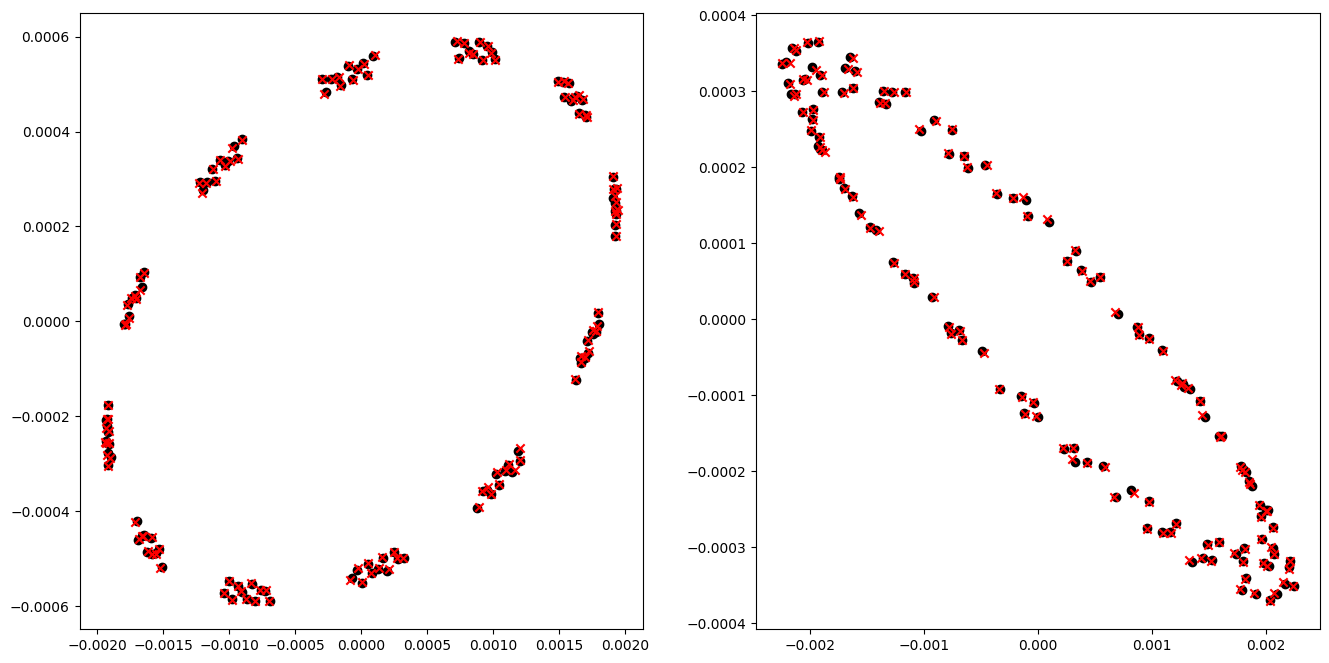

In [25]:
# get_momenta_lstsq method can be used to fit orbit data at virtual locations
# In this case monitors in given range are used to fit both coordinates and momenta at (virtual) location

start = 16
count = 128
probe = 10
limit = 2

# Set reference values

QX, PX, QY, PY = trajectory.swapaxes(0, -1)
QX, PX, QY, PY = QX[start:start + count, probe], PX[start:start + count, probe], QY[start:start + count, probe], PY[start:start + count, probe]

# Note, in this case probe is a location (not monitor location!)

index = model.monitor_index[probe]

# Compute momenta from range of locations (fit)

qx, px, qy, py = twiss.get_momenta_lstsq(start, count, index, limit, model.matrix, phony=True, forward=True, inverse=True)

# Compare

plt.figure(figsize=(2*8, 8))

ax = plt.subplot(121)
ax.scatter(QX, PX, marker='o', color='black')
ax.scatter(qx, px, marker='x', color='red')

ax = plt.subplot(122)
ax.scatter(QY, PY, marker='o', color='black')
ax.scatter(qy, py, marker='x', color='red')

plt.show()

In [26]:
# Compute parameters from virtual signals (frequency, amplitude and phase)

# Here, each signal is treated as virtual
# One can use virtual parameters (amplitudes and phases) for twiss
# Or use phases for transport matrices

In [27]:
# Generate virtual data

# Note, start is shifted to use data from different turns, phase should be adjusted

start = 1
count = length - 1 - start
limit = 2

VQX = torch.zeros_like(X.data)
VPX = torch.zeros_like(X.data)
VQY = torch.zeros_like(Y.data)
VPY = torch.zeros_like(Y.data)

# Note, several last values are zeros

for index, location in enumerate(model.monitor_index):
    
    qx, px, qy, py = twiss.get_momenta_lstsq(start, count, location, limit, model.matrix, phony=True, forward=True, inverse=True)
    
    VQX[index, :count] = qx
    VPX[index, :count] = px
    
    VQY[index, :count] = qy
    VPY[index, :count] = py

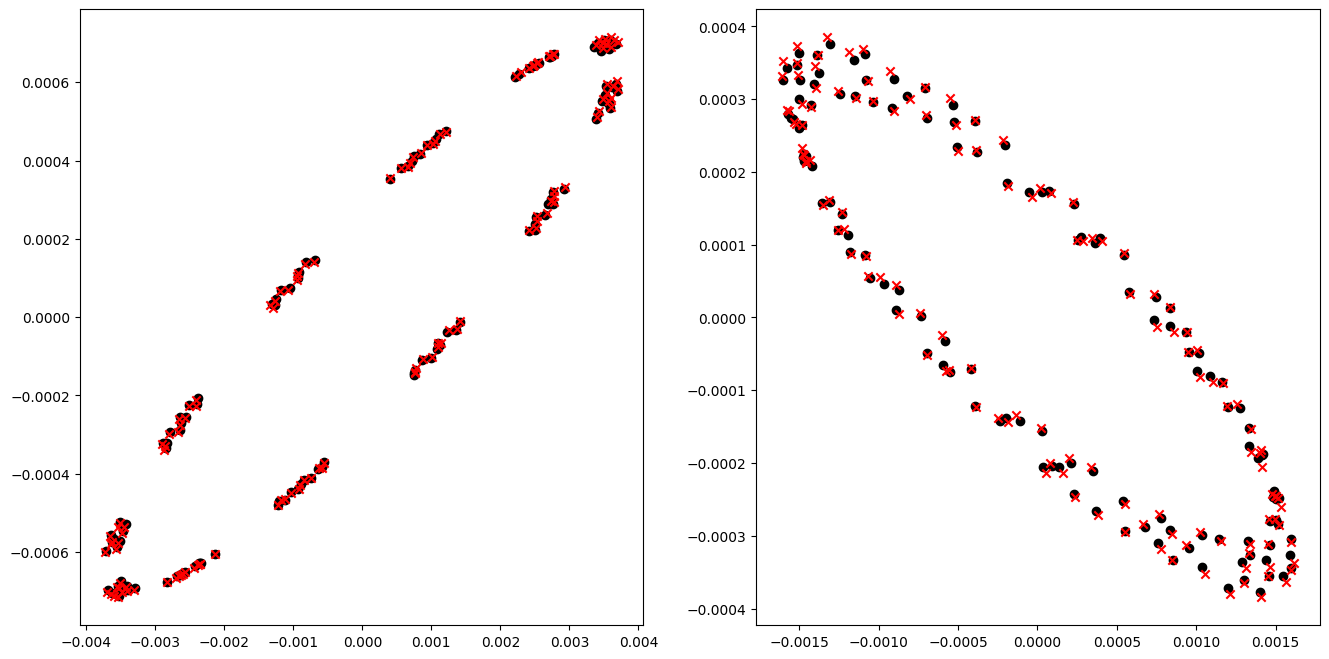

In [28]:
# Compare trajectories

probe = 30
count = 128

QX, PX, QY, PY = trajectory.swapaxes(0, -1)
QX, PX, QY, PY = QX[start:start + count, probe], PX[start:start + count, probe], QY[start:start + count, probe], PY[start:start + count, probe]

qx, px, qy, py = VQX[probe, :count], VPX[probe, :count], VQY[probe, :count], VPY[probe, :count]

plt.figure(figsize=(2*8, 8))

ax = plt.subplot(121)
ax.scatter(QX, PX, marker='o', color='black')
ax.scatter(qx, px, marker='x', color='red')

ax = plt.subplot(122)
ax.scatter(QY, PY, marker='o', color='black')
ax.scatter(qy, py, marker='x', color='red')

plt.show()

In [29]:
# Set TbT

win = Window.from_cosine(length, 1.0, dtype=dtype, device=device)

X = Data.from_data(win, VQX)
Y = Data.from_data(win, VQY)

print(X)
print(Y)

Data(54, Window(1024, 'cosine_window', 1.0))
Data(54, Window(1024, 'cosine_window', 1.0))


In [30]:
# Compute frequency, amplitude and phase for x plane

# Estimate noise

flt = Filter(X)
_, sigma_x = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(X)
X.window_remove_mean()
X.window_apply()
f('parabola')
X.reset()
nux, sigma_nux = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'mqx={mqx.item():12.9}')
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}, error_nux={abs(mqx - nux).item():12.9}')

# Estimate amplitude & phase

d = Decomposition(X)

ax, sigma_ax, _ = d.harmonic_amplitude(nux, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=8, method='noise')
fx, sigma_fx, _ = d.harmonic_phase(nux, length=512, order=0.0, error=True, sigma_frequency=sigma_nux, shift=True, count=256, step=8, method='noise')

mqx= 0.583063972
nux=  0.58306398, sigma_nux=1.21912985e-07, error_nux=7.87083054e-09


In [31]:
# Compute frequency, amplitude and phase for y plane

# Estimate noise

flt = Filter(Y)
_, sigma_y = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(Y)
Y.window_remove_mean()
Y.window_apply()
f('parabola')
Y.reset()
nuy, sigma_nuy = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'mqy={mqy.item():12.9}')
print(f'nuy={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}, error_nuy={abs(mqy - nuy).item():12.9}')

# Estimate amplitude & phase

d = Decomposition(Y)

ay, sigma_ay, _ = d.harmonic_amplitude(nuy, length=256, order=1.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=64, step=8, method='noise')
fy, sigma_fy, _ = d.harmonic_phase(nuy, length=512, order=0.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=256, step=8, method='noise')

mqy= 0.616097169
nuy= 0.616097164, sigma_nuy=1.44637344e-07, error_nuy=4.28743285e-09


In [32]:
# Compare frequencies

print(nux)
print(table.nux)
print()

print(nuy)
print(table.nuy)
print()

tensor(5.830639795072e-01, dtype=torch.float64)
tensor(5.830639723205e-01, dtype=torch.float64)

tensor(6.160971642843e-01, dtype=torch.float64)
tensor(6.160971681855e-01, dtype=torch.float64)



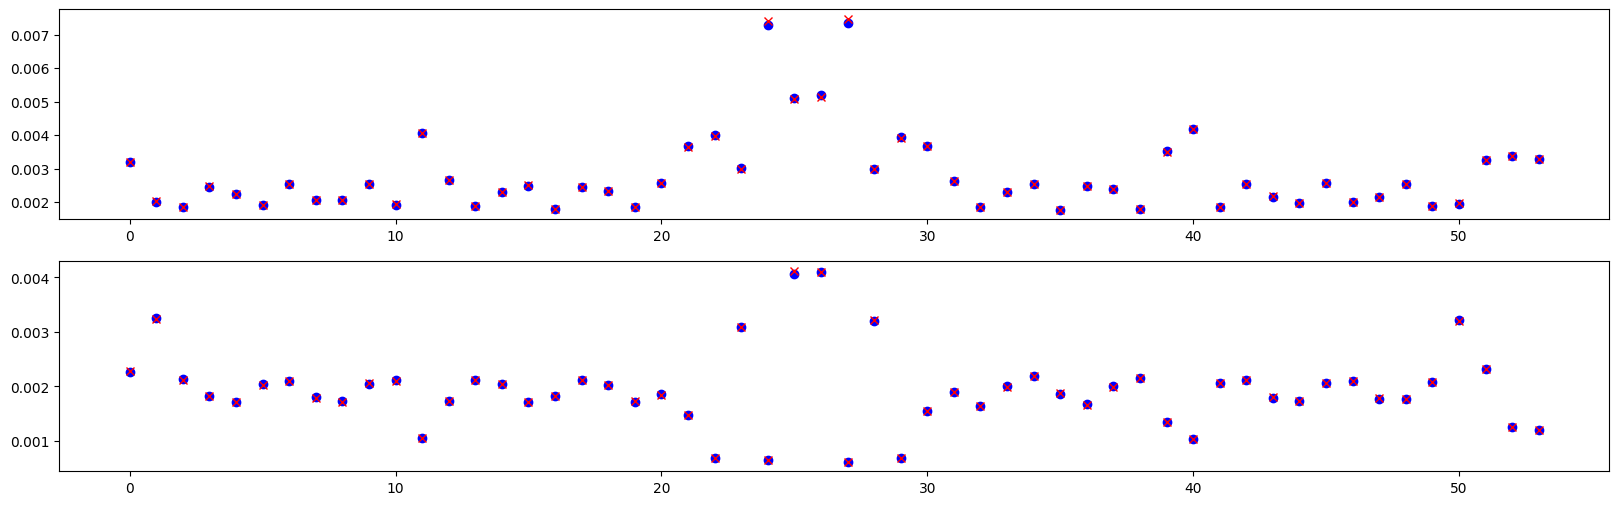

In [33]:
# Compare amplitudes

plt.figure(figsize=(20, 3*2))

ax1 = plt.subplot(211)
ax1.errorbar(range(model.monitor_count), table.ax.cpu().numpy(), yerr=table.sigma_ax.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax1.errorbar(range(model.monitor_count), ax.cpu().numpy(), yerr=sigma_ax.cpu().numpy(), fmt=' ', marker='x', color='red')

ax2 = plt.subplot(212)
ax2.errorbar(range(model.monitor_count), table.ay.cpu().numpy(), yerr=table.sigma_ay.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax2.errorbar(range(model.monitor_count), ay.cpu().numpy(), yerr=sigma_ay.cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

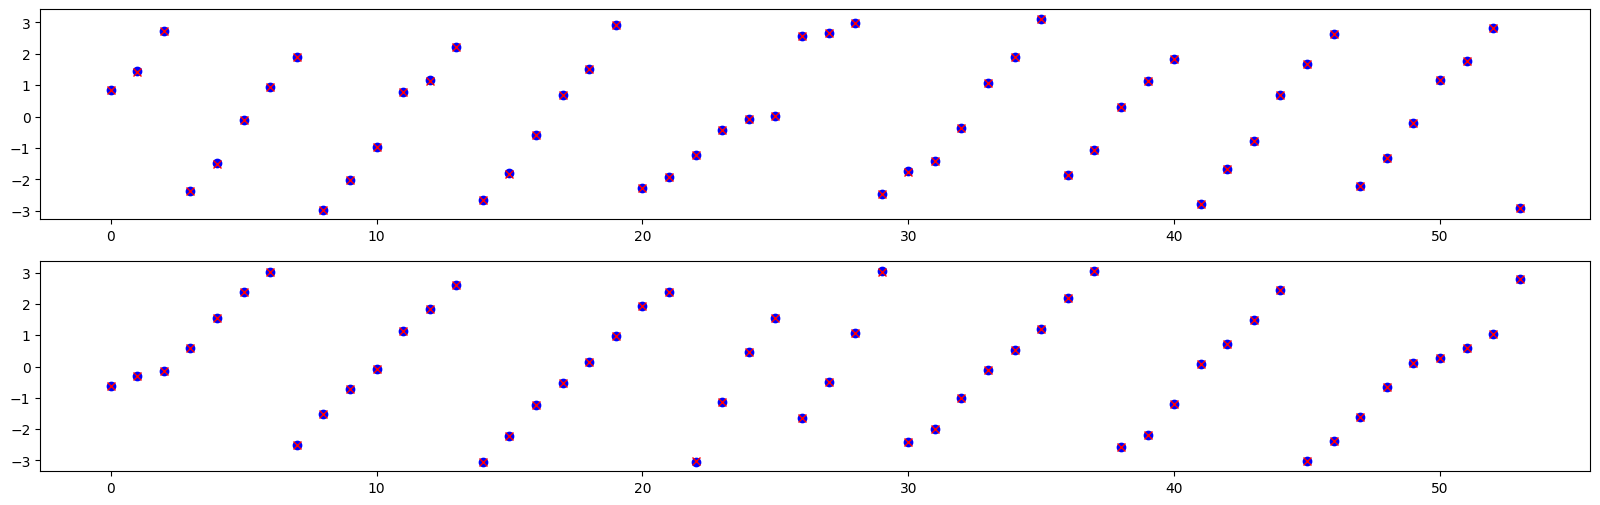

In [34]:
# Compare phases

plt.figure(figsize=(20, 3*2))

ax1 = plt.subplot(211)
ax1.errorbar(range(model.monitor_count), table.fx.cpu().numpy(), yerr=table.sigma_fx.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax1.errorbar(range(model.monitor_count), mod(fx - 2.0*numpy.pi*start*nux, 2.0*numpy.pi, -numpy.pi).cpu().numpy(), yerr=sigma_fx.cpu().numpy(), fmt=' ', marker='x', color='red')

ax2 = plt.subplot(212)
ax2.errorbar(range(model.monitor_count), table.fy.cpu().numpy(), yerr=table.sigma_fy.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax2.errorbar(range(model.monitor_count), mod(fy - 2.0*numpy.pi*start*nuy, 2.0*numpy.pi, -numpy.pi).cpu().numpy(), yerr=sigma_fy.cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()